# SMS Spam Classification

## Executive Summary
This notebook demonstrates an end-to-end Machine Learning NLP pipeline for classifying SMS messages into **Spam** (`True`) or **Ham / Legitimate** (`False`). 

### Workflow Outline
1. **Data Loading & Inspection**: Load labeled training data and unlabeled test dataset.
2. **Exploratory Data Analysis (EDA)**: Analyze class distribution, message lengths, and word frequencies.
3. **Text Feature Extraction**: Benchmark Bag-of-Words (`CountVectorizer`) vs. `TfidfVectorizer`.
4. **Model Benchmarking**: Evaluate Naive Bayes, Logistic Regression, and Support Vector Machines (SVM) using cross-validation and holdout validation.
5. **Model Evaluation**: Assess performance via Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrices.
6. **Final Prediction & Output Generation**: Generate final predictions for the unseen test dataset.

In [7]:
# Core Data Processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Extraction & Model Selection
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
)

# Machine Learning Classifiers
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Environment setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

## 1. Data Loading & Initial Inspection

We load the training set (`data/training_data.txt`) and test set (`data/test_data.txt`). The training set contains tab-separated entries with a boolean label (`True` for Spam, `False` for Ham) and message text.

In [8]:
# Load training and test datasets
df_train = pd.read_csv('../data/training_data.txt', sep="\t", names=['Label', 'Text'])
df_test = pd.read_csv('../data/test_data.txt', sep="\t", names=['Id', 'Text'])

# Standardize Label to binary integer (1 for Spam, 0 for Ham)
df_train['Label'] = df_train['Label'].astype(int)

print("=== Dataset Summary ===")
print(f"Training dataset shape: {df_train.shape[0]:,} rows × {df_train.shape[1]} columns")
print(f"Test dataset shape:     {df_test.shape[0]:,} rows × {df_test.shape[1]} columns\n")

print("Training Data Sample:")
display(df_train.head())

print("\nMissing values in training set:", df_train.isnull().sum().to_dict())
print("Missing values in test set:    ", df_test.isnull().sum().to_dict())

=== Dataset Summary ===
Training dataset shape: 4,343 rows × 2 columns
Test dataset shape:     1,114 rows × 2 columns

Training Data Sample:


,Label,Text
0,1,YOU HAVE WON! As a valued Vodafone customer ou...
1,0,"I‘ve got some salt, you can rub it in my open ..."
2,1,Xmas & New Years Eve tickets are now on sale f...
3,1,3 FREE TAROT TEXTS! Find out about your love l...
4,0,"Like &lt;#&gt; , same question"



Missing values in training set: {'Label': 0, 'Text': 0}
Missing values in test set:     {'Id': 0, 'Text': 0}


## 2. Exploratory Data Analysis (EDA)

Understanding class balance and message characteristics helps guide feature engineering and model evaluation metric selection.

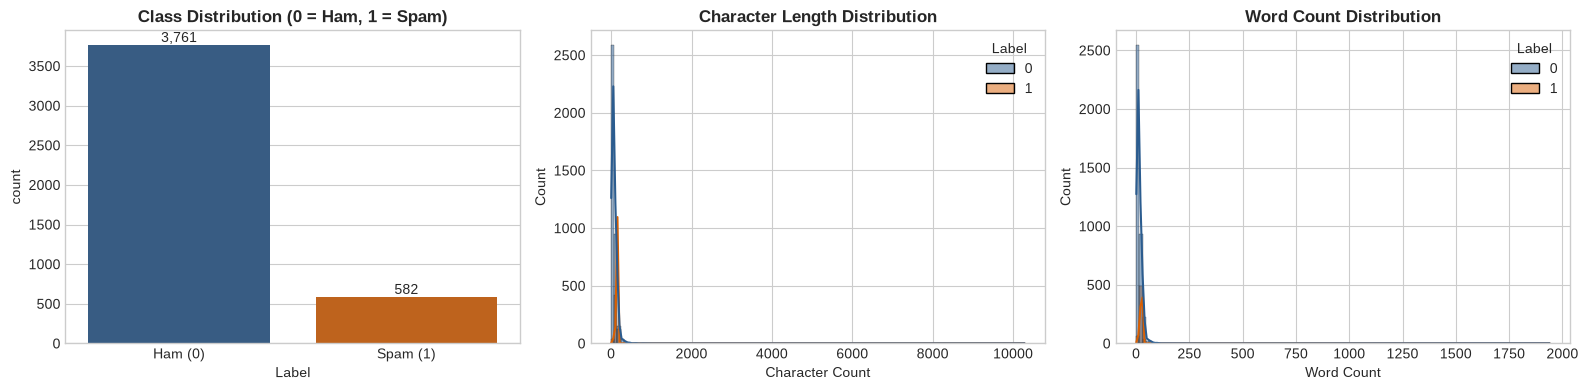

=== Summary Statistics by Message Class ===


Label                         0           1
Char_Length count   3761.000000  582.000000
            mean      74.279181  138.218213
            std      176.924469   28.880765
            min        2.000000   13.000000
            25%       33.000000  133.000000
            50%       51.000000  148.000000
            75%       94.000000  157.000000
            max    10285.000000  197.000000
Word_Count  count   3761.000000  582.000000
            mean      14.851369   23.888316
            std       33.538759    5.769488
            min        1.000000    2.000000
            25%        7.000000   22.000000
            50%       11.000000   25.000000
            75%       19.000000   28.000000
            max     1940.000000   35.000000

In [9]:
# Compute message character and word counts
df_train['Char_Length'] = df_train['Text'].apply(len)
df_train['Word_Count'] = df_train['Text'].apply(lambda x: len(x.split()))

# Setup plots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette = {0: '#2b5c8f', 1: '#d95f02'}

# 1. Class Distribution
sns.countplot(x='Label', hue='Label', data=df_train, ax=axes[0], palette=palette, legend=False)
axes[0].set_title('Class Distribution (0 = Ham, 1 = Spam)', fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Ham (0)', 'Spam (1)'])
for p in axes[0].patches:
    height = int(p.get_height())
    if height > 0:
        axes[0].annotate(f'{height:,}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# 2. Character Length Distribution
sns.histplot(data=df_train, x='Char_Length', hue='Label', kde=True, ax=axes[1], palette=palette)
axes[1].set_title('Character Length Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Character Count')

# 3. Word Count Distribution
sns.histplot(data=df_train, x='Word_Count', hue='Label', kde=True, ax=axes[2], palette=palette)
axes[2].set_title('Word Count Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.show()

# Display summary statistics by class
print("=== Summary Statistics by Message Class ===")
display(df_train.groupby('Label')[['Char_Length', 'Word_Count']].describe().T)

## 3. Feature Extraction & Validation Strategy

To evaluate models realistically without data leakage, we split the training set into an **80% training set** and a **20% validation set** (stratified by target class).

We compare two vectorization techniques:
* **Bag of Words (`CountVectorizer`)**: Word frequency counts (with English stop-word removal).
* **TF-IDF (`TfidfVectorizer`)**: Term Frequency-Inverse Document Frequency scaling.

In [10]:
# Define features and target variable
X = df_train['Text']
y = df_train['Label']
X_unseen_test = df_test['Text']

# Stratified Train-Validation Split (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=== Train-Validation Split Summary ===")
print(f"Training set:   {len(X_train):,} samples (Spam ratio: {y_train.mean():.2%})")
print(f"Validation set: {len(X_val):,} samples (Spam ratio: {y_val.mean():.2%})")

=== Train-Validation Split Summary ===
Training set:   3,474 samples (Spam ratio: 13.41%)
Validation set: 869 samples (Spam ratio: 13.35%)


## 4. Model Benchmarking & Model Selection

We evaluate candidate machine learning models (`MultinomialNB`, `LogisticRegression`, and `SVC`) across both Bag-of-Words (`CountVectorizer`) and TF-IDF (`TfidfVectorizer`) representations.

Key evaluation metrics:
* **Accuracy**: Overall prediction accuracy.
* **Precision**: Ability to avoid misclassifying legitimate messages as spam (False Positives).
* **Recall**: Ability to capture all actual spam messages (False Negatives).
* **F1-Score**: Harmonic mean of Precision and Recall (primary ranking metric).

In [11]:
# Define vectorizer strategies
vectorizer_dict = {
    'CountVectorizer': CountVectorizer(stop_words='english', min_df=1),
    'TfidfVectorizer': TfidfVectorizer(stop_words='english', min_df=1)
}

# Define candidate classification models
classifier_dict = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(random_state=42),
    'Support Vector Machine (Linear)': SVC(kernel='linear', C=1.0, random_state=42)
}

benchmark_results = []

for vec_name, vectorizer in vectorizer_dict.items():
    # Fit vectorizer on training split only
    X_train_vec = vectorizer.fit_transform(X_train)
    X_val_vec = vectorizer.transform(X_val)
    
    for clf_name, classifier in classifier_dict.items():
        # Train model
        classifier.fit(X_train_vec, y_train)
        val_predictions = classifier.predict(X_val_vec)
        
        # Calculate performance metrics
        acc = accuracy_score(y_val, val_predictions)
        prec = precision_score(y_val, val_predictions)
        rec = recall_score(y_val, val_predictions)
        f1 = f1_score(y_val, val_predictions)
        
        benchmark_results.append({
            'Vectorizer': vec_name,
            'Classifier': clf_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

# Create and display benchmark summary table
benchmark_df = pd.DataFrame(benchmark_results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

print("=== Model Benchmarking Performance Table ===")
display(benchmark_df.style.format({
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1-Score': '{:.2%}'
}))

=== Model Benchmarking Performance Table ===


,Vectorizer,Classifier,Accuracy,Precision,Recall,F1-Score
0,CountVectorizer,Multinomial Naive Bayes,99.19%,96.58%,97.41%,97.00%
1,TfidfVectorizer,Support Vector Machine (Linear),98.73%,97.30%,93.10%,95.15%
2,CountVectorizer,Support Vector Machine (Linear),98.62%,100.00%,89.66%,94.55%
3,CountVectorizer,Logistic Regression,98.27%,100.00%,87.07%,93.09%
4,TfidfVectorizer,Multinomial Naive Bayes,97.35%,100.00%,80.17%,89.00%
5,TfidfVectorizer,Logistic Regression,95.86%,97.62%,70.69%,82.00%


## 5. Model Evaluation & Confusion Matrix Analysis

We evaluate the top-performing model pipeline (`MultinomialNB` with `CountVectorizer`) on the validation set using a detailed classification report and confusion matrix.

=== Detailed Classification Report (Validation Split) ===
              precision    recall  f1-score   support

     Ham (0)     0.9960    0.9947    0.9953       753
    Spam (1)     0.9658    0.9741    0.9700       116

    accuracy                         0.9919       869
   macro avg     0.9809    0.9844    0.9827       869
weighted avg     0.9920    0.9919    0.9920       869



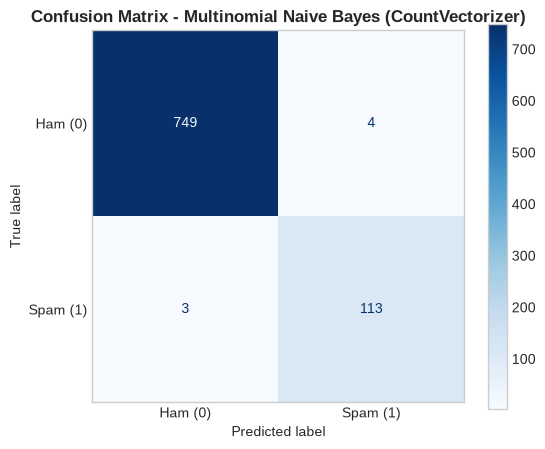

In [12]:
# Instantiate top performing pipeline components
selected_vectorizer = CountVectorizer(stop_words='english', min_df=1)
X_train_transformed = selected_vectorizer.fit_transform(X_train)
X_val_transformed = selected_vectorizer.transform(X_val)

selected_classifier = MultinomialNB()
selected_classifier.fit(X_train_transformed, y_train)
val_preds = selected_classifier.predict(X_val_transformed)

print("=== Detailed Classification Report (Validation Split) ===")
print(classification_report(y_val, val_preds, target_names=['Ham (0)', 'Spam (1)'], digits=4))

# Confusion Matrix Plot
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham (0)', 'Spam (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix - Multinomial Naive Bayes (CountVectorizer)', fontsize=12, fontweight='bold')
plt.grid(False)
plt.show()

## 6. Final Model Retraining & Inference on Test Data

To maximize predictive power on unseen data, we retrain the optimal model pipeline on 100% of the labeled dataset (`df_train`) and generate final predictions for the unseen test set (`df_test`).

In [13]:
# Retrain vectorizer and model on full training set (100% of data)
final_vectorizer = CountVectorizer(stop_words='english', min_df=1)
X_full_vectorized = final_vectorizer.fit_transform(X)
X_test_vectorized = final_vectorizer.transform(X_unseen_test)

final_model = MultinomialNB()
final_model.fit(X_full_vectorized, y)

# Generate predictions for unseen test dataset
test_predictions = final_model.predict(X_test_vectorized)

# Build formatted submission DataFrame
df_submission = pd.DataFrame({
    'id': np.arange(1, len(test_predictions) + 1),
    'label': test_predictions.astype(bool)
})

print("=== Final Test Predictions Summary ===")
print(f"Total unseen test samples: {len(df_submission):,}")
print(f"Predicted Spam messages:   {df_submission['label'].sum():,} ({df_submission['label'].mean():.2%})")
print(f"Predicted Ham messages:    {(~df_submission['label']).sum():,} ({(1 - df_submission['label'].mean()):.2%})\n")

print("Submission Sample Preview:")
display(df_submission.head(10))

=== Final Test Predictions Summary ===
Total unseen test samples: 1,114
Predicted Spam messages:   151 (13.55%)
Predicted Ham messages:    963 (86.45%)

Submission Sample Preview:


,id,label
0,1,False
1,2,False
2,3,False
3,4,False
4,5,False
5,6,False
6,7,False
7,8,False
8,9,False
9,10,False


In [14]:
# Export final predictions to CSV format
output_filepath = '../data/submission.csv'
df_submission.to_csv(output_filepath, index=False)
print(f"Successfully exported predictions to: {output_filepath}")

Successfully exported predictions to: ../data/submission.csv
